# 선형회귀를 활용한 캘리포니아 주택 가격 분석

## 분석 목표

캘리포니아 지역의 소득, 주택 연식, 방 개수 등의 정보를 이용해  
주택 가격을 예측하는 선형회귀 모델을 만들어 보겠습니다

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(display="text")

In [3]:
housing = fetch_california_housing(as_frame=True)

# 1. 데이터 확인

먼저 캘리포니아 주택 가격 데이터의 구조를 확인합니다.

각 행(Row)은 하나의 지역 정보를 의미하며,
각 열(Column)은 해당 지역의 주택 및 인구 특성을 나타냅니다.

첫 5개의 데이터를 확인하여 어떤 변수들이 있는지 살펴보겠습니다.

## 변수 설명

| 변수명 | 의미 |
|--------|------|
| MedInc | 지역의 중위 소득(Median Income) |
| HouseAge | 주택의 평균 연식 |
| AveRooms | 평균 방 개수 |
| AveBedrms | 평균 침실 개수 |
| Population | 지역 인구 수 |
| AveOccup | 평균 거주 인원 |
| Latitude | 위도 |
| Longitude | 경도 |
| MedHouseVal | 주택 가격(예측 대상) |

In [4]:
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 2. 데이터 크기 확인

데이터가 얼마나 많은지 확인합니다.

행(Row)은 데이터 개수,

열(Column)은 변수 개수를 의미합니다.

In [5]:
df.shape

(20640, 9)

# 3. 데이터 정보 확인

각 변수의 자료형(Data Type)과
결측치(Null)가 존재하는지 확인합니다.

결측치가 있다면 전처리가 필요하지만,
이번 데이터는 결측치가 존재하지 않습니다.
모든 변수는 숫자형이며 결측치가 없어 추가적인 전처리 없이 사용할 수 있습니다.

In [6]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# 4. 기초 통계량 확인

데이터의 평균, 표준편차,
최솟값, 최댓값 등을 확인하여
데이터의 전반적인 분포를 살펴봅니다.

In [7]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 5. 입력 변수(X)와 목표 변수(y) 분리

선형회귀 모델은

입력 데이터(X)를 이용하여

목표 데이터(y)를 예측합니다.

이번 분석에서는

주택 가격(MedHouseVal)을

예측 대상으로 설정했습니다.

In [8]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# 6. 학습 데이터와 테스트 데이터 분리

전체 데이터 중

80%는 모델 학습,

20%는 모델 성능 평가에 사용합니다.

학습에 사용되지 않은 데이터로 평가해야
모델의 일반화 성능을 확인할 수 있습니다.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. 선형회귀 모델 생성 및 학습

LinearRegression 모델을 생성하고

fit() 함수를 이용하여

주택 특성과 가격 사이의 관계를 학습합니다.

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print("모델 학습 완료")

모델 학습 완료


In [11]:
y_pred = model.predict(X_test)

# 8. 주택 가격 예측

학습이 완료된 모델을 이용하여

테스트 데이터의 주택 가격을 예측합니다.

In [12]:
result_df = pd.DataFrame({
    "실제값": y_test.values,
    "예측값": y_pred
})

result_df.head(10)

,실제값,예측값
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [13]:
result_df["오차"] = result_df["실제값"] - result_df["예측값"]
result_df.head(10)


,실제값,예측값,오차
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


# 9. 모델 성능 평가

모델이 얼마나 정확하게 예측했는지

MAE

MSE

RMSE

R²

평가지표를 이용하여 확인합니다.
### 평가지표 설명

- MAE : 평균 절대 오차 (작을수록 좋음)

- MSE : 평균 제곱 오차 (작을수록 좋음)

- RMSE : MSE의 제곱근 (작을수록 좋음)

- R² : 모델 설명력 (1에 가까울수록 좋음)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 0.533
MSE: 0.556
RMSE: 0.746
R²: 0.576


In [15]:
y_pred = model.predict(X_test)

print("예측 완료")

예측 완료


# 10. 실제값과 예측값 비교

가로축은 실제 주택 가격,

세로축은 모델이 예측한 가격입니다.

점들이 대각선 방향으로 모일수록
예측 성능이 우수하다고 볼 수 있습니다.

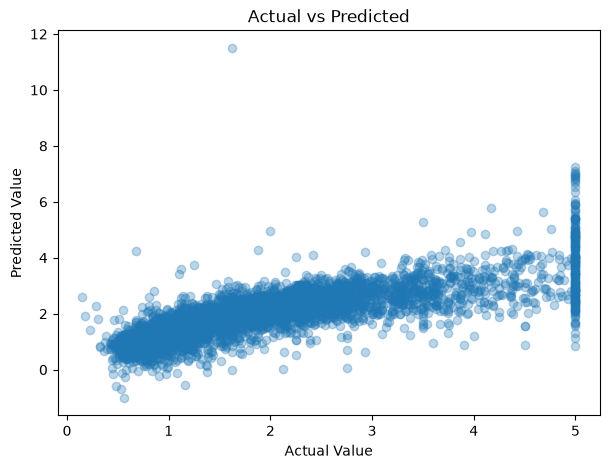

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted")

plt.show()

# 11. 회귀계수 확인

회귀계수(Coef)는

각 변수가 주택 가격에

얼마나 영향을 미치는지 나타냅니다.

양수이면 가격 상승,

음수이면 가격 하락 방향으로

영향을 준다고 해석할 수 있습니다.

In [17]:
coef_df = pd.DataFrame({
    "변수": X.columns,
    "회귀계수": model.coef_
})

coef_df = coef_df.sort_values(
    by="회귀계수",
    ascending=False
)

coef_df

,변수,회귀계수
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


# 12. 절편 확인

절편(Intercept)은

모든 입력 변수가 0일 때의

기본 예측값입니다.

실제 의미보다는

회귀식을 완성하는 역할을 합니다.

In [18]:
print("절편:", model.intercept_)

절편: -37.02327770606416


# 분석 결과

이번 분석에서는

캘리포니아 주택 데이터를 이용하여

선형회귀 모델을 학습하고

주택 가격을 예측해 보았습니다.

모델 성능은

MAE, MSE, RMSE, R²를 이용하여 평가하였으며,

회귀계수를 통해

각 변수가 주택 가격에 미치는 영향도 확인할 수 있었습니다.

선형회귀는 구조가 단순하고 해석이 쉽다는 장점이 있지만,

복잡한 비선형 관계를 표현하기에는 한계가 있습니다.